# LiDAR Ground Plane Estimation (nuScenes)

This notebook:
- Loads a `.bin` LiDAR point cloud from nuScenes
- Visualizes it
- Estimates the ground plane using RANSAC
- Computes the slope of the ground relative to the sensor


In [45]:
# Install dependencies
!pip install open3d numpy matplotlib

## Load nuScenes point cloud

Each point has format:
`[x, y, z, intensity, ring_index]`

We only use XYZ coordinates.

In [46]:
import numpy as np

def load_nuscenes_bin(file_path):
    points = np.fromfile(file_path, dtype=np.float32)
    points = points.reshape(-1, 5)
    xyz = points[:, :3]
    return xyz

# Update this path
file_path = 'C:/Users/JRepa/OneDrive - Delft University of Technology/Documenten/02. TU Delft/2025-2026/BEP/Data/Pointclouds curvature/pointcloud.bin'

points = load_nuscenes_bin(file_path)
print('Loaded points:', points.shape)

Loaded points: (34752, 3)


## Visualize lidar data

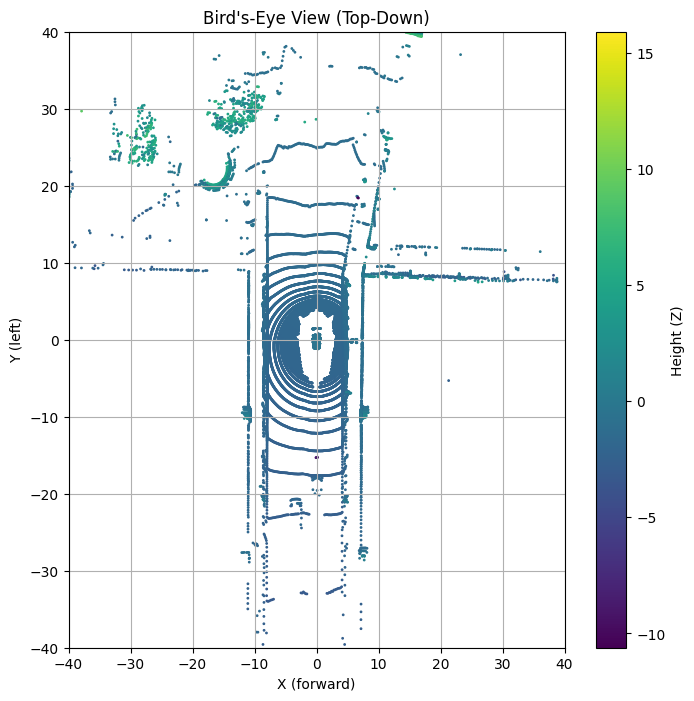

In [47]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_bev(points, max_points=100000):

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    plt.figure(figsize=(8, 8))

    scatter = plt.scatter(
        x, y,
        c=z,                # color by height
        s=1,                # point size
    )

    plt.colorbar(scatter, label="Height (Z)")

    plt.xlabel("X (forward)")
    plt.ylabel("Y (left)")
    plt.title("Bird's-Eye View (Top-Down)")

    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    plt.grid(True)

    plt.show()

visualize_bev(points)

## Estimate ground plane (RANSAC)

Fits a plane: ax + by + cz + d = 0

In [48]:
import open3d as o3d
import numpy as np

def estimate_ground_plane_bottom(points, bottom_fraction=0.2):
    """
    Estimate the ground plane using only the bottom fraction of points (by height).

    Args:
        points: Nx3 array of LiDAR points
        bottom_fraction: fraction of points (lowest Z) to use for plane fitting
    """
    # Select bottom fraction by Z
    z_threshold = np.percentile(points[:,2], bottom_fraction*100)
    bottom_points = points[points[:,2] <= z_threshold]

    print(f"Using {len(bottom_points)} points ({bottom_fraction*100:.0f}% lowest) for ground estimation.")

    # Create Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(bottom_points)

    # RANSAC plane fit
    plane_model, inliers = pcd.segment_plane(
        distance_threshold=0.2,
        ransac_n=3,
        num_iterations=1000
    )

    a, b, c, d = plane_model
    print(f'Plane equation: {a:.4f}x + {b:.4f}y + {c:.4f}z + {d:.4f} = 0')

    # Map inliers back to original points (optional)
    # Here, inliers are indices in bottom_points
    # You could convert to indices in full points if needed

    return plane_model, inliers, bottom_points

# Usage
plane_model, inliers, bottom_points = estimate_ground_plane_bottom(points, bottom_fraction=0.2)

Using 6951 points (20% lowest) for ground estimation.
Plane equation: -0.0061x + -0.0327y + 0.9994z + 1.8699 = 0


## Compute slope of ground plane

- Plane normal = (a, b, c)
- Compare with vertical axis (0,0,1)
- Output slope in degrees

In [49]:
import numpy as np

def compute_slope_fixed(plane_model):
    a, b, c, d = plane_model

    normal = np.array([a, b, c])
    normal = normal / np.linalg.norm(normal)

    z_axis = np.array([0, 0, 1])

    # angle between normal and vertical
    angle_rad = np.arccos(np.clip(np.dot(normal, z_axis), -1.0, 1.0))
    angle_deg = np.degrees(angle_rad)

    slope_deg = angle_deg  # small tilt = small slope

    print(f'Angle between normal and vertical: {angle_deg:.2f}°')
    print(f'Ground slope: {slope_deg:.2f}°')

    return slope_deg

# Usage
slope = compute_slope_fixed(plane_model)

Angle between normal and vertical: 1.91°
Ground slope: 1.91°


# Visualize vertical distance to the ground plane

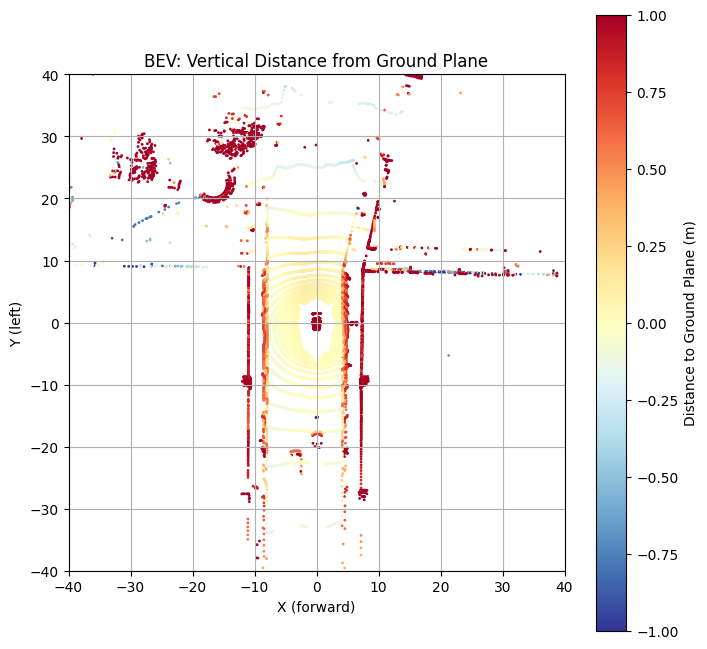

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_bev_distance(points, plane_model, max_points=100000, distance_clip=1.0):
    """
    BEV plot (X-Y) where color encodes vertical distance from the ground plane.

    Args:
        points: Nx3 LiDAR points
        plane_model: [a, b, c, d] plane coefficients
        max_points: maximum points to plot (for speed)
        distance_clip: max abs distance to visualize (m)
    """
    a, b, c, d = plane_model

    # Normalize plane
    norm = np.linalg.norm([a, b, c])
    a, b, c, d = a/norm, b/norm, c/norm, d/norm
    normal = np.array([a, b, c])

    # Signed vertical distance
    distances = points @ normal + d

    x = points[:,0]
    y = points[:,1]

    # Clip distances for visualization
    distances = np.clip(distances, -distance_clip, distance_clip)

    plt.figure(figsize=(8,8))

    sc = plt.scatter(
        x, y,
        c=distances,
        s=1,
        cmap='RdYlBu_r'  # red=above plane, blue=below
    )

    plt.colorbar(sc, label="Distance to Ground Plane (m)")
    plt.xlabel("X (forward)")
    plt.ylabel("Y (left)")
    plt.title("BEV: Vertical Distance from Ground Plane")
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    plt.grid(True)
    plt.show()

# Usage
visualize_bev_distance(points, plane_model)

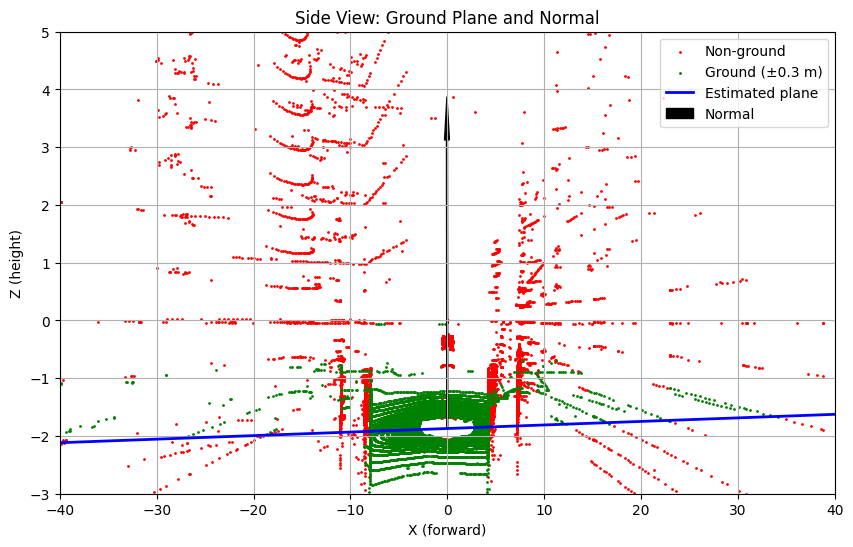

In [51]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_ground_plane_side(points, plane_model, distance_thresh=0.3):
    """
    Side view (X-Z) showing:
    - ground points (green)
    - other points (red)
    - estimated plane (blue line)
    - normal vector (black arrow)
    """

    a, b, c, d = plane_model

    # Normalize plane normal
    normal = np.array([a, b, c])
    normal = normal / np.linalg.norm(normal)
    a, b, c = normal

    # Signed distance of each point to plane
    distances = points @ normal + d
    inliers = np.abs(distances) < distance_thresh

    x = points[:,0]
    z = points[:,2]

    plt.figure(figsize=(10,6))

    # Plot points
    plt.scatter(x[~inliers], z[~inliers], s=1, color='red', label='Non-ground')
    plt.scatter(x[inliers], z[inliers], s=1, color='green', label=f'Ground (±{distance_thresh} m)')

    # Plane line (Y≈0 slice)
    xs = np.linspace(-40, 40, 500)
    zs = (-a*xs - d)/c
    plt.plot(xs, zs, color='blue', linewidth=2, label='Estimated plane')

    # Normal vector from point on plane at x=0, y=0
    origin = np.array([0, 0, -d/c])
    scale = 5
    normal_end = origin + normal * scale
    plt.arrow(
        origin[0], origin[2],
        normal[0]*scale, normal[2]*scale,
        color='black', width=0.1, head_width=0.5,
        label='Normal'
    )

    plt.xlabel("X (forward)")
    plt.ylabel("Z (height)")
    plt.title("Side View: Ground Plane and Normal")
    plt.xlim(-40, 40)
    plt.ylim(-3, 5)
    plt.grid(True)
    plt.legend()
    plt.show()

# Usage
visualize_ground_plane_side(points, plane_model)

# Grid-based Ground Curvature Estimation

Divides the point cloud into a grid of cells. For each cell:
- Selects points near the reference ground plane
- Fits a local plane using RANSAC
- Computes the local slope relative to vertical

The result is a curvature map showing how the ground tilts across the scene.

In [54]:

def compute_grid_slopes(points, plane_model, grid_size=5.0, distance_thresh=0.5, min_points=10):
    """
    Divide the point cloud into grid cells, fit a local plane per cell,
    and compute slope relative to vertical.

    Args:
        points:          Nx3 LiDAR points
        plane_model:     reference plane [a, b, c, d] (used to isolate ground points)
        grid_size:       width/height of each grid cell in meters
        distance_thresh: max distance from reference plane to be considered ground
        min_points:      minimum points required to fit a plane in a cell
    Returns:
        list of (cx, cy, slope_deg, normal_xy) per grid cell
    """
    a, b, c, d = plane_model
    normal = np.array([a, b, c])
    normal = normal / np.linalg.norm(normal)

    # Keep only points close to the reference ground plane
    distances = points @ normal + d
    ground_points = points[np.abs(distances) < distance_thresh]
    print(f"Ground points used for grid fitting: {len(ground_points)}")

    x_min, x_max = ground_points[:, 0].min(), ground_points[:, 0].max()
    y_min, y_max = ground_points[:, 1].min(), ground_points[:, 1].max()

    x_bins = np.arange(x_min, x_max + grid_size, grid_size)
    y_bins = np.arange(y_min, y_max + grid_size, grid_size)

    z_axis = np.array([0, 0, 1])
    results = []

    for i in range(len(x_bins) - 1):
        for j in range(len(y_bins) - 1):
            mask = (
                (ground_points[:, 0] >= x_bins[i]) & (ground_points[:, 0] < x_bins[i+1]) &
                (ground_points[:, 1] >= y_bins[j]) & (ground_points[:, 1] < y_bins[j+1])
            )
            cell_pts = ground_points[mask]

            if len(cell_pts) < min_points:
                continue

            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(cell_pts)

            try:
                local_plane, _ = pcd.segment_plane(
                    distance_threshold=0.1,
                    ransac_n=3,
                    num_iterations=100
                )
                la, lb, lc, ld = local_plane
                local_normal = np.array([la, lb, lc])
                local_normal = local_normal / np.linalg.norm(local_normal)

                slope = np.degrees(np.arccos(np.clip(np.dot(local_normal, z_axis), -1, 1)))

                # XY component of the normal = direction the plane tilts
                tilt_xy = local_normal[:2]
                tilt_magnitude = np.linalg.norm(tilt_xy)
                tilt_dir = tilt_xy / tilt_magnitude if tilt_magnitude > 1e-6 else np.array([0, 0])

                cx = (x_bins[i] + x_bins[i+1]) / 2
                cy = (y_bins[j] + y_bins[j+1]) / 2
                results.append((cx, cy, slope, tilt_dir, tilt_magnitude))
            except Exception:
                continue

    return results


def visualize_curvature_map(results, grid_size=5.0):
    """
    Plot a heatmap of local ground slope per grid cell, with:
    - arrows showing the tilt direction of each local plane
    - sensor location marker at the origin
    - sensor forward (+X) and left (+Y) direction arrows
    """
    if not results:
        print("No cells with enough points to fit a plane.")
        return

    xs     = np.array([r[0] for r in results])
    ys     = np.array([r[1] for r in results])
    slopes = np.array([r[2] for r in results])
    dirs   = np.array([r[3] for r in results])   # unit tilt direction (XY)
    mags   = np.array([r[4] for r in results])   # tilt magnitude

    vmax = np.percentile(slopes, 95)
    arrow_scale = grid_size * 0.45  # arrow length relative to cell size

    fig, ax = plt.subplots(figsize=(11, 10))

    # --- grid cell slope heatmap ---
    sc = ax.scatter(
        xs, ys,
        c=slopes,
        cmap='RdYlGn_r',
        s=(grid_size * 9) ** 2,
        marker='s',
        vmin=0, vmax=vmax,
        zorder=1
    )
    plt.colorbar(sc, ax=ax, label='Local slope (degrees)')

    # --- tilt direction arrows per cell ---
    for i in range(len(xs)):
        if mags[i] > 1e-6:
            ax.annotate(
                '', 
                xy=(xs[i] + dirs[i, 0] * arrow_scale, ys[i] + dirs[i, 1] * arrow_scale),
                xytext=(xs[i], ys[i]),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                zorder=3
            )

    # --- sensor location dot ---
    ax.plot(0, 0, 'o', color='dodgerblue', markersize=10, zorder=5, label='Sensor location')

    # --- sensor orientation arrows ---
    sensor_arrow_len = grid_size * 1.5
    ax.annotate(
        'Forward (+X)',
        xy=(sensor_arrow_len, 0), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=2.5),
        fontsize=9, color='dodgerblue', zorder=5,
        xycoords='data', textcoords='data',
        ha='left', va='bottom'
    )
    ax.annotate(
        'Left (+Y)',
        xy=(0, sensor_arrow_len), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.5),
        fontsize=9, color='darkorange', zorder=5,
        xycoords='data', textcoords='data',
        ha='left', va='bottom'
    )

    ax.set_xlabel('X (forward, m)')
    ax.set_ylabel('Y (left, m)')
    ax.set_title(f'Ground Curvature Map  (grid cell = {grid_size} m)\nBlack arrows = tilt direction of local plane')
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='upper right')
    ax.grid(True, linewidth=0.4)
    plt.tight_layout()
    plt.show()

    print(f"\nSlope statistics across {len(slopes)} cells:")
    print(f"  Min:  {slopes.min():.2f} deg")
    print(f"  Max:  {slopes.max():.2f} deg")
    print(f"  Mean: {slopes.mean():.2f} deg")
    print(f"  Std:  {slopes.std():.2f} deg")


Ground points used for grid fitting: 18700
Fitted local planes in 296 grid cells


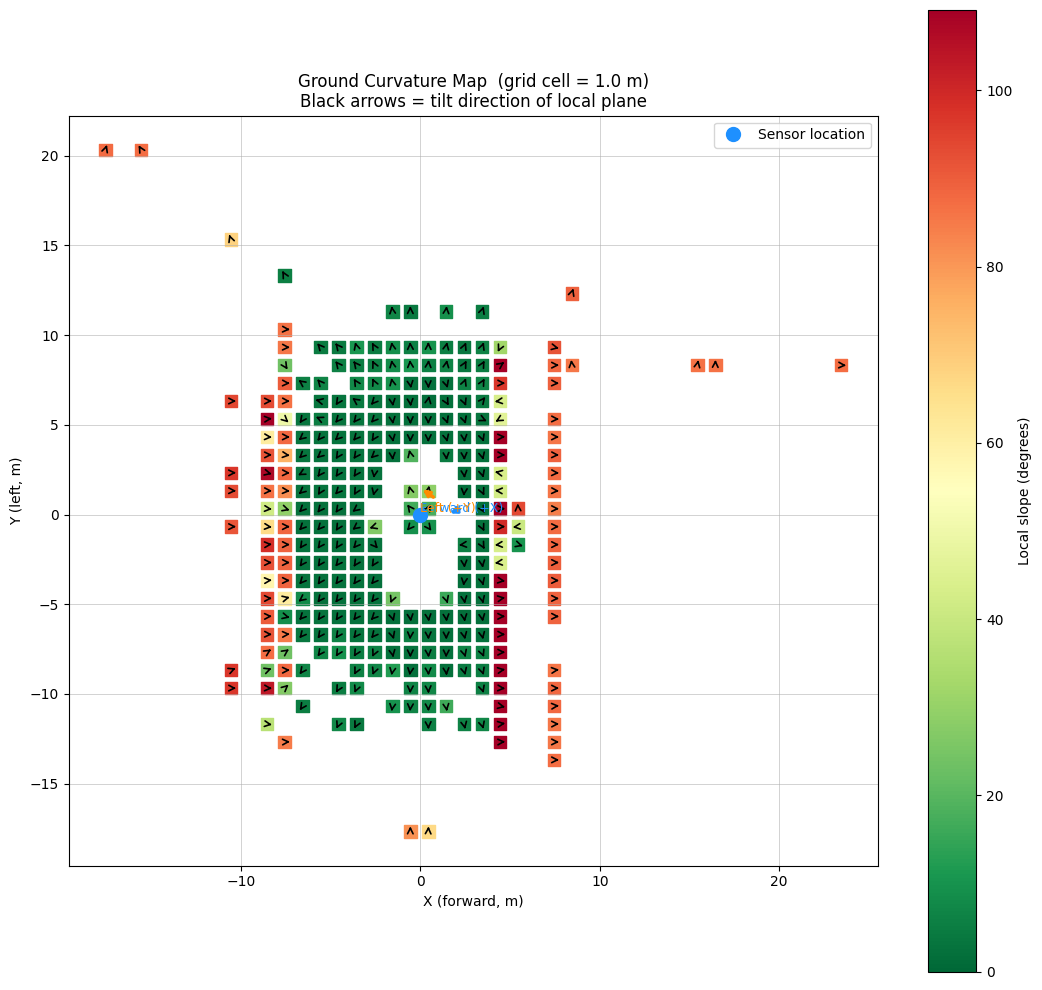


Slope statistics across 296 cells:
  Min:  1.36 deg
  Max:  133.62 deg
  Mean: 32.27 deg
  Std:  41.31 deg


In [53]:
# --- parameters ---
GRID_SIZE       = 1.0   # meters per cell (try 2.5 for finer detail)
DIST_THRESH     = 1.5   # max distance from reference plane to count as ground
MIN_POINTS_CELL = 15    # minimum points needed to fit a plane in a cell

grid_results = compute_grid_slopes(
    points, plane_model,
    grid_size=GRID_SIZE,
    distance_thresh=DIST_THRESH,
    min_points=MIN_POINTS_CELL
)

print(f"Fitted local planes in {len(grid_results)} grid cells")
visualize_curvature_map(grid_results, grid_size=GRID_SIZE)
